## 1. Setup and load inputs

I load:
- Prices and returns (Notebook 01, 02)
- Covariance matrix $\Sigma$ (Notebook 02)
- Expected returns from MLR (Notebook 05), MA (Notebook 04), and historical realized returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# Plot styling (consistent across notebooks)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

np.random.seed(42)

# Annualization factor for HOSE
TRADING_DAYS = 250
RISK_FREE_RATE = 0.04  # Vietnam 10Y government bond ~4% (proxy)

# ============================================================
# Load all inputs from previous notebooks
# ============================================================

# 1. Prices and returns (NB01, NB02)
prices = pd.read_csv('../data/prices.csv', index_col='time', parse_dates=True)
returns = pd.read_csv('../data/returns.csv', index_col='time', parse_dates=True)

# 2. Covariance matrix (NB02) — annualized
cov_matrix = pd.read_csv('../data/cov_matrix.csv', index_col=0)

# 3. MLR-implied expected returns (NB05) — main input
mlr_mu = pd.read_csv('../data/mlr_expected_returns.csv', index_col=0)
mlr_mu = mlr_mu['mu_annualized']  # convert to Series

# 4. MA-implied expected returns (NB04) — baseline comparison
ma_mu = pd.read_csv('../data/ma_expected_returns.csv', index_col=0)
ma_mu = ma_mu.iloc[:, 0]  # take first column (annualized μ)

# 5. Historical realized returns (NB02) — sanity check
historical_mu = returns.mean() * TRADING_DAYS

# ============================================================
# Verify inputs
# ============================================================
TICKERS = prices.columns.tolist()
N_STOCKS = len(TICKERS)

print(f'Number of stocks:  {N_STOCKS}')
print(f'Tickers:           {TICKERS}')
print(f'Trading period:    {prices.index.min().date()} → {prices.index.max().date()}')
print(f'Risk-free rate:    {RISK_FREE_RATE*100:.1f}% (annualized)')

print(f'\n--- Expected returns comparison (annualized %) ---')
mu_comparison = pd.DataFrame({
    'Historical': historical_mu * 100,
    'MA5-implied': ma_mu * 100,
    'MLR-implied': mlr_mu * 100,
})
print(mu_comparison.round(2))

print(f'\n--- Covariance matrix Σ ---')
print(f'Shape: {cov_matrix.shape}')
print(cov_matrix.round(4))

# Sanity check: tickers align
assert all(cov_matrix.index == TICKERS), 'Σ tickers misaligned!'
assert all(mlr_mu.index == TICKERS), 'MLR μ tickers misaligned!'
print(f'\n✓ All inputs aligned on {N_STOCKS} tickers')

Number of stocks:  8
Tickers:           ['VNM', 'VIC', 'VHM', 'FPT', 'HPG', 'MWG', 'VCB', 'MBB']
Trading period:    2021-11-01 → 2025-04-29
Risk-free rate:    4.0% (annualized)

--- Expected returns comparison (annualized %) ---
     Historical  MA5-implied  MLR-implied
VNM       -5.68          8.0        20.92
VIC       -4.87         13.4        21.27
VHM       -4.75         11.3         7.05
FPT       22.39        -12.4        40.22
HPG       -5.76         14.6       -37.93
MWG        5.23          6.9       -24.94
VCB       11.41         -4.5       -20.16
MBB       13.75         -3.4       -30.97

--- Covariance matrix Σ ---
Shape: (8, 8)
        VNM     VIC     VHM     FPT     HPG     MWG     VCB     MBB
VNM  0.0002  0.0001  0.0001  0.0001  0.0001  0.0001  0.0001  0.0001
VIC  0.0001  0.0004  0.0002  0.0001  0.0001  0.0001  0.0001  0.0001
VHM  0.0001  0.0002  0.0004  0.0001  0.0002  0.0002  0.0001  0.0001
FPT  0.0001  0.0001  0.0001  0.0003  0.0002  0.0002  0.0001  0.0002
HPG  0.000

In [2]:
# ============================================================
# Implement core portfolio functions
# ============================================================
# Three building blocks:
#   1. Portfolio expected return:    μ_p = μ^T w
#   2. Portfolio volatility:         σ_p = sqrt(w^T Σ w)
#   3. Sharpe ratio:                 (μ_p - r_f) / σ_p
# ============================================================

def portfolio_return(weights, mu):
    """Compute portfolio expected return: μ_p = μ^T w.
    
    Linear algebra: matrix-vector product (1D × 1D = scalar).
    
    Parameters
    ----------
    weights : ndarray, shape (n,)
        Portfolio weights summing to 1.
    mu : ndarray, shape (n,)
        Expected return vector (annualized).
    
    Returns
    -------
    scalar : portfolio expected return (annualized).
    """
    return np.dot(mu, weights)

def portfolio_volatility(weights, sigma):
    """Compute portfolio volatility: σ_p = sqrt(w^T Σ w).
    
    Linear algebra: quadratic form (1D × 2D × 1D = scalar).
    Note: Σ is daily covariance, so I multiply by TRADING_DAYS
    to annualize the variance before taking sqrt.
    
    Parameters
    ----------
    weights : ndarray, shape (n,)
        Portfolio weights.
    sigma : ndarray, shape (n, n)
        Daily covariance matrix.
    
    Returns
    -------
    scalar : portfolio volatility (annualized).
    """
    daily_var = weights @ sigma @ weights  # quadratic form
    annual_var = daily_var * TRADING_DAYS
    return np.sqrt(annual_var)

def sharpe_ratio(weights, mu, sigma, rf=RISK_FREE_RATE):
    """Compute portfolio Sharpe ratio: (μ_p - r_f) / σ_p."""
    mu_p = portfolio_return(weights, mu)
    sigma_p = portfolio_volatility(weights, sigma)
    if sigma_p < 1e-10:  # avoid division by zero
        return 0.0
    return (mu_p - rf) / sigma_p

# ============================================================
# Sanity check: test on equal-weight portfolio
# ============================================================
print('--- Sanity check: equal-weight portfolio (1/N) ---')

w_equal = np.ones(N_STOCKS) / N_STOCKS  # all weights = 1/8 = 0.125
print(f'Equal weights: {w_equal}')
print(f'Sum of weights: {w_equal.sum():.4f} (should be 1.0)')

# Convert pandas inputs to numpy for the functions
mu_mlr_arr = mlr_mu.values
sigma_arr  = cov_matrix.values

ret_eq    = portfolio_return(w_equal, mu_mlr_arr)
vol_eq    = portfolio_volatility(w_equal, sigma_arr)
sharpe_eq = sharpe_ratio(w_equal, mu_mlr_arr, sigma_arr)

print(f'\nUsing MLR-implied μ:')
print(f'  Portfolio return     μ_p = {ret_eq*100:+.2f}%/year')
print(f'  Portfolio volatility σ_p = {vol_eq*100:.2f}%/year')
print(f'  Sharpe ratio              = {sharpe_eq:.4f}')

# Also compute for Historical and MA5 μ for comparison
print(f'\n--- Equal-weight portfolio with different μ estimates ---')
for name, mu_est in [('Historical', historical_mu.values),
                     ('MA5-implied', ma_mu.values),
                     ('MLR-implied', mu_mlr_arr)]:
    r = portfolio_return(w_equal, mu_est)
    s = sharpe_ratio(w_equal, mu_est, sigma_arr)
    print(f'  {name:15s}: return = {r*100:+6.2f}%,  Sharpe = {s:+.4f}')

--- Sanity check: equal-weight portfolio (1/N) ---
Equal weights: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
Sum of weights: 1.0000 (should be 1.0)

Using MLR-implied μ:
  Portfolio return     μ_p = -3.07%/year
  Portfolio volatility σ_p = 20.09%/year
  Sharpe ratio              = -0.3516

--- Equal-weight portfolio with different μ estimates ---
  Historical     : return =  +3.97%,  Sharpe = -0.0017
  MA5-implied    : return =  +4.24%,  Sharpe = +0.0118
  MLR-implied    : return =  -3.07%,  Sharpe = -0.3516


In [3]:
# ============================================================
# Objective function: negative Sharpe ratio
# ============================================================
# scipy.optimize.minimize is a minimizer, so to MAXIMIZE Sharpe,
# I minimize the NEGATIVE Sharpe ratio:
#
#   min  -Sharpe(w) = -(μ^T w - r_f) / sqrt(w^T Σ w)
#    w
# ============================================================

def neg_sharpe(weights, mu, sigma, rf=RISK_FREE_RATE):
    """Negative Sharpe ratio (to be MINIMIZED by scipy).
    
    Minimizing this is equivalent to maximizing the Sharpe ratio.
    
    Parameters
    ----------
    weights : ndarray, shape (n,)
        Portfolio weights.
    mu : ndarray, shape (n,)
        Expected return vector (annualized).
    sigma : ndarray, shape (n, n)
        Daily covariance matrix.
    rf : float
        Risk-free rate (annualized).
    
    Returns
    -------
    scalar : negative Sharpe ratio.
    """
    return -sharpe_ratio(weights, mu, sigma, rf)

# ============================================================
# Sanity check: evaluate at equal-weight portfolio
# ============================================================
print('--- Objective function evaluated at equal-weight portfolio ---')

mu_mlr_arr = mlr_mu.values
sigma_arr  = cov_matrix.values

ns = neg_sharpe(w_equal, mu_mlr_arr, sigma_arr)
print(f'  neg_sharpe(w_equal) = {ns:+.4f}')
print(f'  Expected:           = {-sharpe_eq:+.4f}  (= -Sharpe(w_equal))')

assert abs(ns - (-sharpe_eq)) < 1e-10, 'neg_sharpe mismatch!'
print(f'  ✓ neg_sharpe correctly returns the negative of Sharpe')

--- Objective function evaluated at equal-weight portfolio ---
  neg_sharpe(w_equal) = +0.3516
  Expected:           = +0.3516  (= -Sharpe(w_equal))
  ✓ neg_sharpe correctly returns the negative of Sharpe


## 4. Constraints and initial guess

I encode two practical investment constraints:

### Constraint 1 — Budget (fully invested)

$$\sum_{i=1}^{8} w_i = 1$$

The portfolio uses 100% of capital, with no cash position and no leverage. In scipy, this is an **equality constraint**: `np.sum(w) - 1 == 0`.

### Constraint 2 — Long-only

$$0 \leq w_i \leq 1 \quad \forall i$$

No short selling and no single-stock concentration above 100% (the latter follows automatically from the budget constraint when combined with non-negativity). In scipy, these are passed as **bounds** rather than constraints, which the SLSQP solver handles more efficiently.

In [4]:
# ============================================================
# Constraints + initial guess for optimization
# ============================================================
# Constraint 1 (equality): sum(w) = 1     → fully invested
# Constraint 2 (bounds):   0 <= w_i <= 1  → long-only, no leverage
# Initial guess: equal-weight (1/N) — feasible starting point
# ============================================================

# Budget constraint: sum(w) - 1 == 0
budget_constraint = {
    'type': 'eq',
    'fun':  lambda w: np.sum(w) - 1
}

# Long-only bounds: each w_i in [0, 1]
bounds = tuple((0.0, 1.0) for _ in range(N_STOCKS))

# Initial guess: equal-weight portfolio
w_init = np.ones(N_STOCKS) / N_STOCKS

# ============================================================
# Verify constraints on initial guess
# ============================================================
print('--- Verifying constraints on initial guess (equal-weight) ---')
print(f'Initial weights: {w_init}')
print(f'\nBudget constraint check:')
print(f'  sum(w_init) = {np.sum(w_init):.6f}')
print(f'  Constraint value (should be 0): {np.sum(w_init) - 1:.6e}')

print(f'\nLong-only check:')
all_nonneg = np.all(w_init >= 0)
all_leq1   = np.all(w_init <= 1)
print(f'  All w_i >= 0: {all_nonneg}')
print(f'  All w_i <= 1: {all_leq1}')

print(f'\nBounds applied to each weight:')
for i, t in enumerate(TICKERS):
    print(f'  {t}: w in [{bounds[i][0]}, {bounds[i][1]}]')

print(f'\n✓ Initial guess is feasible (satisfies both constraints)')

--- Verifying constraints on initial guess (equal-weight) ---
Initial weights: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]

Budget constraint check:
  sum(w_init) = 1.000000
  Constraint value (should be 0): 0.000000e+00

Long-only check:
  All w_i >= 0: True
  All w_i <= 1: True

Bounds applied to each weight:
  VNM: w in [0.0, 1.0]
  VIC: w in [0.0, 1.0]
  VHM: w in [0.0, 1.0]
  FPT: w in [0.0, 1.0]
  HPG: w in [0.0, 1.0]
  MWG: w in [0.0, 1.0]
  VCB: w in [0.0, 1.0]
  MBB: w in [0.0, 1.0]

✓ Initial guess is feasible (satisfies both constraints)


In [5]:
# ============================================================
# Optimize portfolio: maximize Sharpe ratio
# ============================================================
# Method: SLSQP (Sequential Least Squares Programming)
# - Handles equality constraints (budget) + bounds (long-only)
# - Smooth gradient-based — fast for small problems
# - scipy.optimize default for this problem class
# ============================================================

def optimize_portfolio(mu, sigma, rf=RISK_FREE_RATE, verbose=True):
    """Find weights that maximize Sharpe ratio (long-only, fully invested).
    
    Parameters
    ----------
    mu : ndarray, shape (n,)
        Expected return vector (annualized).
    sigma : ndarray, shape (n, n)
        Daily covariance matrix.
    rf : float
        Risk-free rate (annualized).
    verbose : bool
        Print optimization details.
    
    Returns
    -------
    w_opt : ndarray, shape (n,)
        Optimal portfolio weights.
    result : scipy OptimizeResult object
        Full optimization output.
    """
    result = minimize(
        fun=neg_sharpe,
        x0=w_init,
        args=(mu, sigma, rf),
        method='SLSQP',
        bounds=bounds,
        constraints=[budget_constraint],
        options={'ftol': 1e-10, 'maxiter': 200, 'disp': verbose}
    )
    
    w_opt = result.x
    
    if verbose:
        print(f'  Converged: {result.success}')
        print(f'  Iterations: {result.nit}')
        print(f'  Optimal -Sharpe: {result.fun:+.4f}')
        print(f'  Optimal Sharpe:  {-result.fun:+.4f}')
    
    return w_opt, result

# ============================================================
# Run optimization for 3 different μ estimates
# ============================================================
historical_mu_arr = historical_mu.values
ma_mu_arr         = ma_mu.values
mlr_mu_arr        = mlr_mu.values

optimal_portfolios = {}

for name, mu_est in [('Historical', historical_mu_arr),
                     ('MA5',        ma_mu_arr),
                     ('MLR',        mlr_mu_arr)]:
    print(f'\n========== Optimizing with {name}-implied μ ==========')
    w_opt, result = optimize_portfolio(mu_est, sigma_arr, verbose=True)
    optimal_portfolios[name] = {
        'weights': w_opt,
        'mu':      mu_est,
        'result':  result,
    }

# ============================================================
# Display optimal weights
# ============================================================
print(f'\n\n========== Optimal portfolio weights ==========')
weights_df = pd.DataFrame({
    name: optimal_portfolios[name]['weights']
    for name in ['Historical', 'MA5', 'MLR']
}, index=TICKERS)

print((weights_df * 100).round(2).astype(str) + '%')

# ============================================================
# Verify each portfolio satisfies constraints
# ============================================================
print(f'\n========== Constraint verification ==========')
for name in ['Historical', 'MA5', 'MLR']:
    w = optimal_portfolios[name]['weights']
    s = w.sum()
    nz = (w > 1e-4).sum()  # count non-trivial positions
    print(f'  {name}: sum(w) = {s:.6f}, '
          f'non-zero positions = {nz}/{N_STOCKS}, '
          f'min(w) = {w.min():.4f}')


========== Optimizing with Historical-implied μ ==========
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.6859514727140865
            Iterations: 7
            Function evaluations: 63
            Gradient evaluations: 7
  Converged: True
  Iterations: 7
  Optimal -Sharpe: -0.6860
  Optimal Sharpe:  +0.6860

========== Optimizing with MA5-implied μ ==========
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.38107213955134633
            Iterations: 9
            Function evaluations: 81
            Gradient evaluations: 9
  Converged: True
  Iterations: 9
  Optimal -Sharpe: -0.3811
  Optimal Sharpe:  +0.3811

========== Optimizing with MLR-implied μ ==========
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.3797812681632888
            Iterations: 9
            Function evaluations: 81
            Gradient evaluations: 9
  Converged: True
  Iterations

## 6. Sparsity and concentrated portfolios

### Observation: the optimizer naturally produces sparse solutions

The portfolios from Section 5 contain only **2–3 non-zero positions** out of 8 candidate stocks, even without an explicit L1 sparsity penalty. This is not a coincidence; it reflects a mathematical property of the **long-only Sharpe-maximization problem**:

- The Sharpe ratio is **scale-invariant**: scaling all weights by a constant does not change Sharpe.
- The budget constraint $\sum_i w_i = 1$ + long-only bound $w_i \geq 0$ creates a **simplex** as the feasible region.
- The optimizer pushes capital toward the few stocks with the best risk-adjusted contribution, leaving the rest at the boundary ($w_i = 0$).

This is analogous to the **KKT (Karush-Kuhn-Tucker) conditions** for inequality-constrained optimization: at the optimum, either the bound is active ($w_i = 0$) or the marginal Sharpe contribution equates across all in-portfolio stocks.

In [6]:
# ============================================================
# Sparse portfolio variant (post-processing)
# ============================================================
# The optimizer already produces sparse solutions (2-3 stocks).
# This step cleans tiny numerical artifacts and demonstrates
# the L1-equivalent post-processing approach.
# ============================================================

SPARSITY_THRESHOLD = 0.01  # 1% — clean up rounding noise

def sparsify_weights(w, threshold=SPARSITY_THRESHOLD):
    """Zero-out small weights, then renormalize to sum = 1."""
    w_sparse = w.copy()
    w_sparse[w_sparse < threshold] = 0.0
    total = w_sparse.sum()
    if total > 0:
        w_sparse = w_sparse / total
    return w_sparse

# Apply to all 3 portfolios
sparse_portfolios = {}
for name in ['Historical', 'MA5', 'MLR']:
    w_dense = optimal_portfolios[name]['weights']
    w_sparse = sparsify_weights(w_dense)
    sparse_portfolios[name] = {
        'weights': w_sparse,
        'mu': optimal_portfolios[name]['mu'],
    }

# Display side-by-side
print('========== Dense vs Sparse weights (threshold = 1%) ==========')
comparison = pd.DataFrame(index=TICKERS)
for name in ['Historical', 'MA5', 'MLR']:
    comparison[f'{name}-dense']  = optimal_portfolios[name]['weights']
    comparison[f'{name}-sparse'] = sparse_portfolios[name]['weights']

print((comparison * 100).round(2).astype(str) + '%')

# Position count
print('\n========== Position count: dense vs sparse ==========')
for name in ['Historical', 'MA5', 'MLR']:
    nz_dense  = (optimal_portfolios[name]['weights'] > 1e-4).sum()
    nz_sparse = (sparse_portfolios[name]['weights'] > 1e-4).sum()
    print(f'  {name:12s}: dense = {nz_dense} positions, sparse = {nz_sparse} positions')

========== Dense vs Sparse weights (threshold = 1%) ==========
    Historical-dense Historical-sparse MA5-dense MA5-sparse MLR-dense  \
VNM             0.0%              0.0%    16.48%     16.48%     17.6%   
VIC             0.0%              0.0%    42.76%     42.76%    10.65%   
VHM             0.0%              0.0%      0.0%       0.0%      0.0%   
FPT            86.8%             86.8%      0.0%       0.0%    71.75%   
HPG             0.0%              0.0%    40.77%     40.77%      0.0%   
MWG             0.0%              0.0%      0.0%       0.0%      0.0%   
VCB            13.2%             13.2%      0.0%       0.0%      0.0%   
MBB             0.0%              0.0%      0.0%       0.0%      0.0%   

    MLR-sparse  
VNM      17.6%  
VIC     10.65%  
VHM       0.0%  
FPT     71.75%  
HPG       0.0%  
MWG       0.0%  
VCB       0.0%  
MBB       0.0%  

========== Position count: dense vs sparse ==========
  Historical  : dense = 2 positions, sparse = 2 positions
  MA5        

## 7. Performance evaluation

Now I evaluate all portfolios side-by-side on three dimensions:

1. **Risk–return profile**: annualized return, volatility, and Sharpe ratio.
2. **Concentration**: number of active positions + Herfindahl-Hirschman Index (HHI).
3. **Comparison vs benchmark**: how much Sharpe improvement does optimization deliver over the naïve 1/N equal-weight portfolio?

**HHI (Herfindahl-Hirschman Index)** measures concentration:

$$\text{HHI} = \sum_{i=1}^{N} w_i^2 \quad \in \left[\tfrac{1}{N}, 1\right]$$

- HHI = 1/N (= 0.125 for N=8) → perfectly diversified (equal-weight).
- HHI = 1 → fully concentrated in a single stock.
- **Effective number of stocks** = 1 / HHI : an intuitive read of "how many stocks the portfolio behaves like."

In [7]:
# ============================================================
# Performance evaluation: all portfolios side-by-side
# ============================================================
# Compare on 3 dimensions:
#   1. Risk-return:   return, volatility, Sharpe
#   2. Concentration: active stocks, HHI, effective N
#   3. vs benchmark:  ΔSharpe over 1/N equal-weight
# ============================================================

def evaluate_portfolio(w, mu, sigma, rf=RISK_FREE_RATE):
    """Compute full risk-return + concentration metrics for one portfolio."""
    mu_p   = portfolio_return(w, mu)
    sig_p  = portfolio_volatility(w, sigma)
    sr     = sharpe_ratio(w, mu, sigma, rf)
    n_act  = int((w > 1e-4).sum())
    hhi    = float(np.sum(w ** 2))          # concentration: sum(w_i^2)
    eff_n  = 1.0 / hhi if hhi > 0 else 0.0  # effective number of stocks
    return {
        'Return (%)':     mu_p * 100,
        'Volatility (%)': sig_p * 100,
        'Sharpe':         sr,
        'Active Stocks':  n_act,
        'HHI':            hhi,
        'Effective N':    eff_n,
    }

# ============================================================
# Build comparison table
# ============================================================
rows = []

# (a) 1/N benchmark — evaluated with each μ estimate
for name, mu_est in [('Historical', historical_mu.values),
                     ('MA5',        ma_mu.values),
                     ('MLR',        mlr_mu.values)]:
    m = evaluate_portfolio(w_equal, mu_est, sigma_arr)
    m['Portfolio'] = f'1/N Benchmark ({name} μ)'
    rows.append(m)

# (b) Optimal portfolios — dense
for name in ['Historical', 'MA5', 'MLR']:
    w  = optimal_portfolios[name]['weights']
    mu = optimal_portfolios[name]['mu']
    m  = evaluate_portfolio(w, mu, sigma_arr)
    m['Portfolio'] = f'Optimal-{name} (dense)'
    rows.append(m)

# (c) Optimal portfolios — sparse
for name in ['Historical', 'MA5', 'MLR']:
    w  = sparse_portfolios[name]['weights']
    mu = sparse_portfolios[name]['mu']
    m  = evaluate_portfolio(w, mu, sigma_arr)
    m['Portfolio'] = f'Optimal-{name} (sparse)'
    rows.append(m)

perf_df = pd.DataFrame(rows).set_index('Portfolio')[
    ['Return (%)', 'Volatility (%)', 'Sharpe',
     'Active Stocks', 'HHI', 'Effective N']
]

print('=' * 75)
print('PORTFOLIO PERFORMANCE EVALUATION (annualized)')
print('=' * 75)
print(perf_df.round(4).to_string())

# ============================================================
# Key insights
# ============================================================
print('\n' + '=' * 75)
print('KEY INSIGHTS')
print('=' * 75)

best_idx    = perf_df['Sharpe'].idxmax()
best_sharpe = perf_df['Sharpe'].max()
print(f'\n→ Best portfolio: {best_idx}')
print(f'   Sharpe     = {best_sharpe:+.4f}')
print(f'   Return     = {perf_df.loc[best_idx, "Return (%)"]:+.2f}%/year')
print(f'   Volatility = {perf_df.loc[best_idx, "Volatility (%)"]:.2f}%/year')

print(f'\n→ Sharpe improvement of optimal vs 1/N benchmark (using same μ):')
for name in ['Historical', 'MA5', 'MLR']:
    bench_sr = perf_df.loc[f'1/N Benchmark ({name} μ)', 'Sharpe']
    opt_sr   = perf_df.loc[f'Optimal-{name} (dense)', 'Sharpe']
    print(f'   {name:11s}: '
          f'1/N Sharpe = {bench_sr:+.4f}  →  '
          f'Optimal Sharpe = {opt_sr:+.4f}  '
          f'(Δ = {opt_sr - bench_sr:+.4f})')

# Save results
perf_df.to_csv('../data/portfolio_performance.csv')
print(f'\n✓ Performance table saved to ../data/portfolio_performance.csv')

PORTFOLIO PERFORMANCE EVALUATION (annualized)
                              Return (%)  Volatility (%)  Sharpe  Active Stocks     HHI  Effective N
Portfolio                                                                                           
1/N Benchmark (Historical μ)      3.9656         20.0944 -0.0017              8  0.1250       8.0000
1/N Benchmark (MA5 μ)             4.2375         20.0944  0.0118              8  0.1250       8.0000
1/N Benchmark (MLR μ)            -3.0655         20.0944 -0.3516              8  0.1250       8.0000
Optimal-Historical (dense)       20.9397         24.6952  0.6860              2  0.7709       1.2972
Optimal-MA5 (dense)              12.9995         23.6162  0.3811              3  0.3762       2.6585
Optimal-MLR (dense)              34.8083         22.3284  1.3798              3  0.5571       1.7949
Optimal-Historical (sparse)      20.9397         24.6952  0.6860              2  0.7709       1.2972
Optimal-MA5 (sparse)             12.9995     

## 8. Visualization

I produce four figures to communicate the results:

1. **Portfolio weights bar chart** — compares allocation across 3 μ-estimates against the 1/N benchmark line.
2. **MLR portfolio pie chart** — focuses on the best-performing portfolio (the headline result).
3. **Risk-return scatter** — overlays 3,000 random feasible portfolios with the optimal points, making the optimization "advantage" visually obvious.
4. **Sharpe ratio comparison** — quantifies the value-add of optimization over the naïve 1/N benchmark.

All figures are saved to `figures/` for inclusion in the final report.

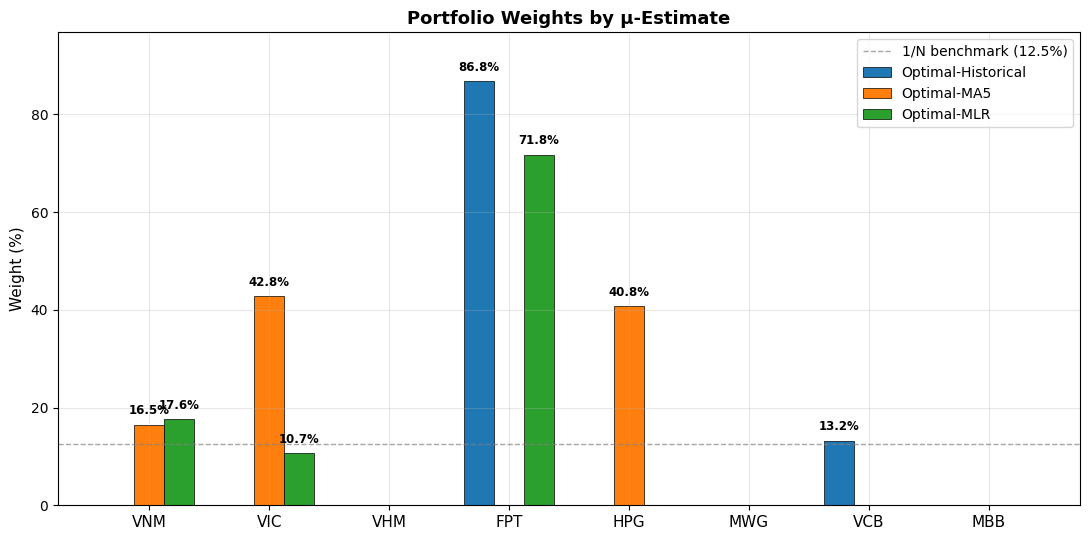

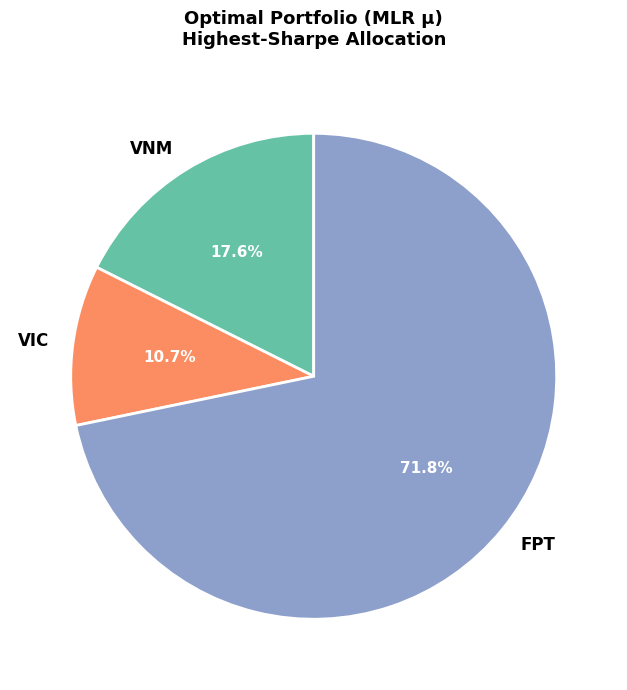

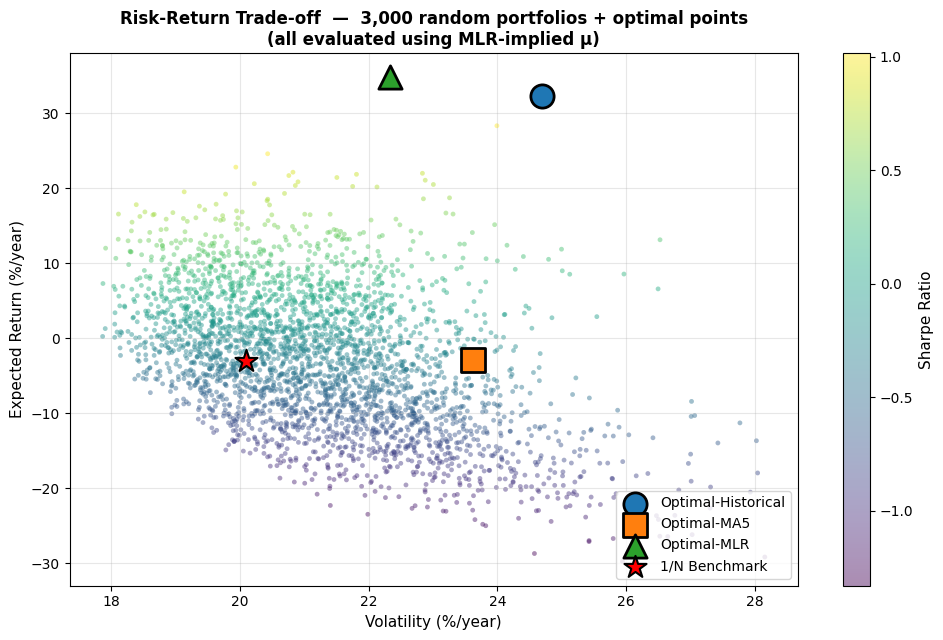

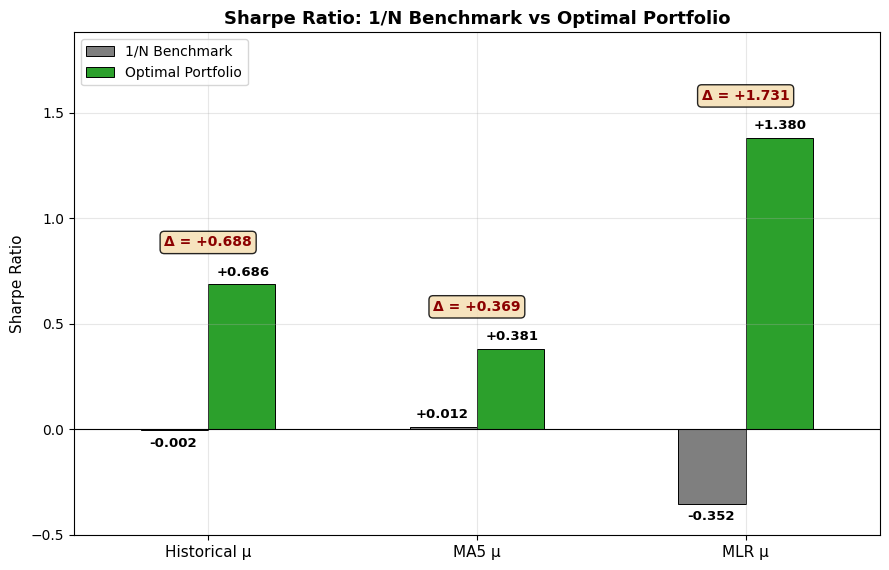


✓ All 4 figures saved to ../figures/


In [8]:
# ============================================================
# Visualization: 4 key figures for the report
# ============================================================
import os
os.makedirs('../figures', exist_ok=True)

# Consistent color scheme across figures
COLORS = {
    'Historical': '#1f77b4',
    'MA5':        '#ff7f0e',
    'MLR':        '#2ca02c',
    'Benchmark':  '#7f7f7f',
}

# ----------------------------------------------------------------
# FIGURE 1 — Portfolio weights (grouped bar chart)
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(N_STOCKS)
width = 0.25

for i, name in enumerate(['Historical', 'MA5', 'MLR']):
    w = optimal_portfolios[name]['weights'] * 100
    bars = ax.bar(x + (i - 1) * width, w, width,
                  label=f'Optimal-{name}',
                  color=COLORS[name], edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, w):
        if v > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
                    f'{v:.1f}%', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold')

ax.axhline(y=100/N_STOCKS, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'1/N benchmark ({100/N_STOCKS:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontsize=11)
ax.set_ylabel('Weight (%)', fontsize=11)
ax.set_title('Portfolio Weights by μ-Estimate', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', frameon=True)
max_w = max([optimal_portfolios[n]['weights'].max() for n in ['Historical','MA5','MLR']])
ax.set_ylim(0, max_w*100 + 10)
plt.tight_layout()
plt.savefig('../figures/portfolio_weights.png', dpi=120, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# FIGURE 2 — Pie chart of best portfolio (MLR)
# ----------------------------------------------------------------
w_mlr  = optimal_portfolios['MLR']['weights']
mask   = w_mlr > 1e-4
labels = [t for t, m in zip(TICKERS, mask) if m]
sizes  = w_mlr[mask] * 100

fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = sns.color_palette('Set2', n_colors=len(labels))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(11)

ax.set_title('Optimal Portfolio (MLR μ)\nHighest-Sharpe Allocation',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/portfolio_mlr_pie.png', dpi=120, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# FIGURE 3 — Risk-return scatter (feasible set + optimal points)
# ----------------------------------------------------------------
# Generate random feasible portfolios for the scatter cloud
N_RANDOM = 3000
np.random.seed(42)
random_returns = np.zeros(N_RANDOM)
random_vols    = np.zeros(N_RANDOM)
random_sharpes = np.zeros(N_RANDOM)

mu_for_scatter = mlr_mu.values  # use MLR μ for a single coherent risk-return space

for i in range(N_RANDOM):
    w = np.random.dirichlet(np.ones(N_STOCKS))   # random w on the simplex
    random_returns[i] = portfolio_return(w, mu_for_scatter)
    random_vols[i]    = portfolio_volatility(w, sigma_arr)
    random_sharpes[i] = sharpe_ratio(w, mu_for_scatter, sigma_arr)

fig, ax = plt.subplots(figsize=(10, 6.5))
sc = ax.scatter(random_vols*100, random_returns*100, c=random_sharpes,
                cmap='viridis', alpha=0.45, s=12, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio', fontsize=11)

# Overlay 3 optimal portfolios (all evaluated on MLR μ for fair visual comparison)
markers = {'Historical': 'o', 'MA5': 's', 'MLR': '^'}
for name in ['Historical', 'MA5', 'MLR']:
    w = optimal_portfolios[name]['weights']
    r = portfolio_return(w, mu_for_scatter) * 100
    v = portfolio_volatility(w, sigma_arr) * 100
    ax.scatter(v, r, s=280, marker=markers[name], color=COLORS[name],
               edgecolors='black', linewidths=2,
               label=f'Optimal-{name}', zorder=5)

# Equal-weight benchmark
r_eq = portfolio_return(w_equal, mu_for_scatter) * 100
v_eq = portfolio_volatility(w_equal, sigma_arr) * 100
ax.scatter(v_eq, r_eq, s=280, marker='*', color='red',
           edgecolors='black', linewidths=1.5,
           label='1/N Benchmark', zorder=5)

ax.set_xlabel('Volatility (%/year)', fontsize=11)
ax.set_ylabel('Expected Return (%/year)', fontsize=11)
ax.set_title('Risk-Return Trade-off  —  3,000 random portfolios + optimal points\n'
             '(all evaluated using MLR-implied μ)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('../figures/risk_return_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# FIGURE 4 — Sharpe ratio: benchmark vs optimal (key headline chart)
# ----------------------------------------------------------------
sharpe_data = pd.DataFrame({
    '1/N Benchmark': [
        sharpe_ratio(w_equal, historical_mu.values, sigma_arr),
        sharpe_ratio(w_equal, ma_mu.values,         sigma_arr),
        sharpe_ratio(w_equal, mlr_mu.values,        sigma_arr),
    ],
    'Optimal Portfolio': [
        sharpe_ratio(optimal_portfolios['Historical']['weights'], historical_mu.values, sigma_arr),
        sharpe_ratio(optimal_portfolios['MA5']['weights'],        ma_mu.values,         sigma_arr),
        sharpe_ratio(optimal_portfolios['MLR']['weights'],        mlr_mu.values,        sigma_arr),
    ],
}, index=['Historical μ', 'MA5 μ', 'MLR μ'])

fig, ax = plt.subplots(figsize=(9, 5.8))
sharpe_data.plot(kind='bar', ax=ax,
                 color=['#7f7f7f', '#2ca02c'], edgecolor='black', linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio: 1/N Benchmark vs Optimal Portfolio',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(sharpe_data.index, rotation=0, fontsize=11)
ax.legend(loc='upper left', frameon=True)

# Annotate values + ΔSharpe boxes
for i, (idx, row) in enumerate(sharpe_data.iterrows()):
    # bar value labels
    ax.text(i - 0.13, row['1/N Benchmark'] + (0.04 if row['1/N Benchmark'] >= 0 else -0.08),
            f'{row["1/N Benchmark"]:+.3f}',
            ha='center', fontsize=9.5, fontweight='bold')
    ax.text(i + 0.13, row['Optimal Portfolio'] + 0.04,
            f'{row["Optimal Portfolio"]:+.3f}',
            ha='center', fontsize=9.5, fontweight='bold')
    # delta box
    delta = row['Optimal Portfolio'] - row['1/N Benchmark']
    ax.text(i, max(row['Optimal Portfolio'], 0) + 0.18,
            f'Δ = {delta:+.3f}', ha='center', fontsize=10,
            fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.85))

# Extra headroom so the ΔSharpe boxes don't clip
ax.set_ylim(sharpe_data.min().min() - 0.15,
            sharpe_data.max().max() + 0.5)

plt.tight_layout()
plt.savefig('../figures/sharpe_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n✓ All 4 figures saved to ../figures/')

## 9. Out-of-sample backtest

The Sharpe ratios in Section 7 are **in-sample** — computed using the same data that produced μ and Σ. This is optimistic by construction. A more honest test is the **out-of-sample backtest**:

1. **Train period (~75%)**: estimate μ, Σ, and optimize weights `w` using only this data.
2. **Test period (~25%)**: hold weights fixed and apply them to the realized returns of the unseen test period.

If the portfolio still beats the 1/N benchmark out-of-sample, the optimization is genuinely useful. If not, it has been overfitting to historical noise — a well-known weakness of Markowitz-style Mean-Variance Optimization.

I evaluate three out-of-sample metrics:

- **Cumulative wealth curve** — what happens to a 100-unit investment over the test period.
- **Out-of-sample Sharpe** — risk-adjusted return on data the optimizer never saw.
- **Maximum drawdown** — the worst peak-to-trough loss, a key risk metric.

Train: 2021-11-02 → 2024-06-14 (652 days)
Test:  2024-06-17 → 2025-04-29 (218 days)

Train Sharpe: 1.1766
Optimal weights (trained on train set):
  FPT: 92.07%
  VCB: 7.93%

OUT-OF-SAMPLE PERFORMANCE
                            Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe  Max Drawdown (%)
Portfolio                                                                                                
Optimal (trained on train)          -14.6929           -16.6598         26.6686 -0.7747          -30.5117
1/N Benchmark                         9.7384            11.2456         18.8354  0.3847          -15.1991


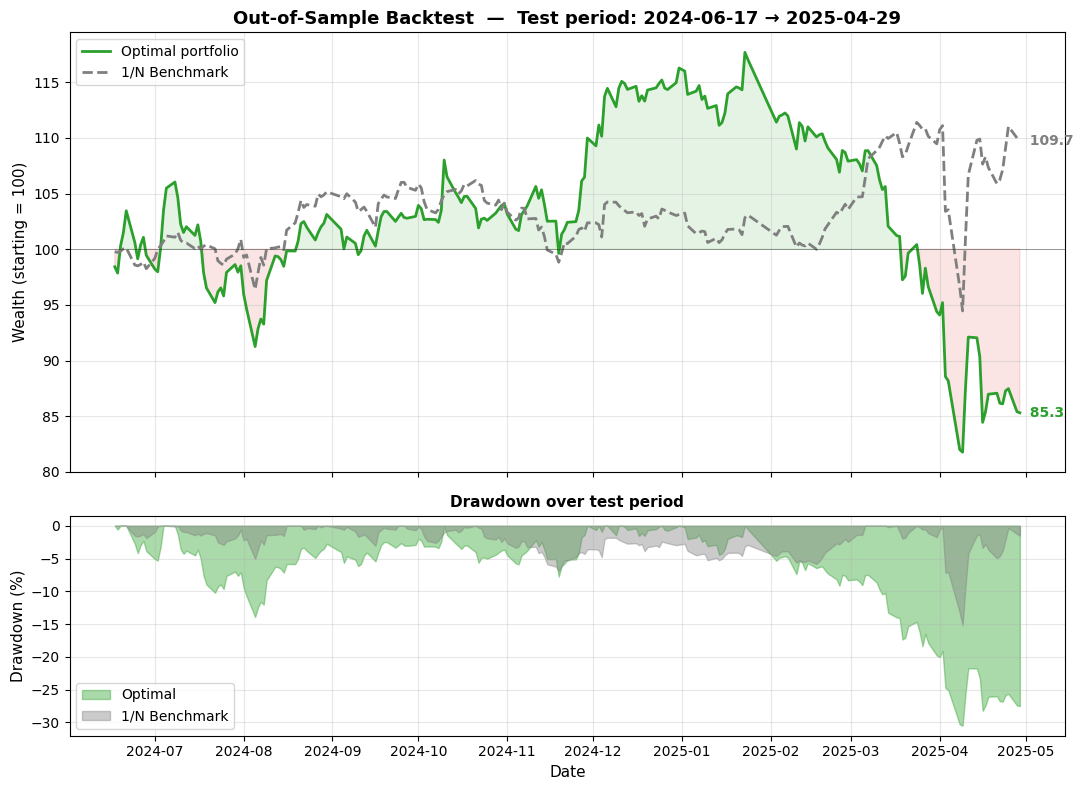

In [10]:
# ============================================================
# Out-of-sample backtest: train/test split
# ============================================================
# Train (~75%) — fit weights here
# Test  (~25%) — apply weights, measure realized performance
# ============================================================

SPLIT_RATIO = 0.75
split_idx   = int(len(returns) * SPLIT_RATIO)

train_returns = returns.iloc[:split_idx]
test_returns  = returns.iloc[split_idx:]

print(f'Train: {train_returns.index[0].date()} → {train_returns.index[-1].date()} '
      f'({len(train_returns)} days)')
print(f'Test:  {test_returns.index[0].date()} → {test_returns.index[-1].date()} '
      f'({len(test_returns)} days)')

# ----------------------------------------------------------------
# Train: estimate μ, Σ — and optimize — using ONLY train data
# ----------------------------------------------------------------
mu_train_arr    = (train_returns.mean() * TRADING_DAYS).values
sigma_train_arr = train_returns.cov().values

result = minimize(
    fun=neg_sharpe, x0=w_init,
    args=(mu_train_arr, sigma_train_arr),
    method='SLSQP', bounds=bounds, constraints=[budget_constraint],
    options={'ftol': 1e-10, 'maxiter': 200}
)
w_backtest = result.x

print(f'\nTrain Sharpe: {-result.fun:.4f}')
print('Optimal weights (trained on train set):')
for t, w in zip(TICKERS, w_backtest):
    if w > 1e-4:
        print(f'  {t}: {w*100:.2f}%')

# ----------------------------------------------------------------
# Test: apply weights to UNSEEN data
# ----------------------------------------------------------------
test_daily_optimal = test_returns.values @ w_backtest  # daily portfolio returns
test_daily_equal   = test_returns.values @ w_equal

# Cumulative wealth (start = 100)
wealth_optimal = 100 * (1 + test_daily_optimal).cumprod()
wealth_equal   = 100 * (1 + test_daily_equal).cumprod()

def compute_oos_metrics(daily, name):
    """Out-of-sample performance metrics from a daily return series."""
    n = len(daily)
    total_ret  = (1 + daily).prod() - 1
    annual_ret = (1 + total_ret) ** (TRADING_DAYS / n) - 1
    annual_vol = np.std(daily, ddof=1) * np.sqrt(TRADING_DAYS)
    sr = (annual_ret - RISK_FREE_RATE) / annual_vol if annual_vol > 1e-10 else 0.0
    # Max drawdown
    w = (1 + daily).cumprod()
    peak = np.maximum.accumulate(w)
    max_dd = ((w - peak) / peak).min()
    return {
        'Portfolio':         name,
        'Total Return (%)':  total_ret * 100,
        'Annual Return (%)': annual_ret * 100,
        'Annual Vol (%)':    annual_vol * 100,
        'Sharpe':            sr,
        'Max Drawdown (%)':  max_dd * 100,
    }

backtest_df = pd.DataFrame([
    compute_oos_metrics(test_daily_optimal, 'Optimal (trained on train)'),
    compute_oos_metrics(test_daily_equal,   '1/N Benchmark'),
]).set_index('Portfolio')

print('\n' + '=' * 70)
print('OUT-OF-SAMPLE PERFORMANCE')
print('=' * 70)
print(backtest_df.round(4).to_string())

# Save
backtest_df.to_csv('../data/backtest_results.csv')

# ----------------------------------------------------------------
# Figure: wealth curves + drawdown
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# (a) Wealth curves
ax = axes[0]
test_dates = test_returns.index
ax.plot(test_dates, wealth_optimal, label='Optimal portfolio',
        color='#2ca02c', linewidth=2)
ax.plot(test_dates, wealth_equal,   label='1/N Benchmark',
        color='#7f7f7f', linewidth=2, linestyle='--')
ax.axhline(100, color='black', linewidth=0.6, alpha=0.4)
ax.fill_between(test_dates, 100, wealth_optimal,
                where=(wealth_optimal >= 100), alpha=0.12, color='#2ca02c')
ax.fill_between(test_dates, 100, wealth_optimal,
                where=(wealth_optimal < 100),  alpha=0.12, color='#d62728')
ax.set_ylabel('Wealth (starting = 100)', fontsize=11)
ax.set_title(f'Out-of-Sample Backtest  —  Test period: '
             f'{test_dates[0].date()} → {test_dates[-1].date()}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', frameon=True, fontsize=10)
ax.annotate(f'  {wealth_optimal[-1]:.1f}',
            xy=(test_dates[-1], wealth_optimal[-1]),
            fontsize=10, fontweight='bold', color='#2ca02c', va='center')
ax.annotate(f'  {wealth_equal[-1]:.1f}',
            xy=(test_dates[-1], wealth_equal[-1]),
            fontsize=10, fontweight='bold', color='#7f7f7f', va='center')

# (b) Drawdown
def drawdown_pct(daily):
    w = (1 + daily).cumprod()
    return (w - np.maximum.accumulate(w)) / np.maximum.accumulate(w) * 100

ax = axes[1]
ax.fill_between(test_dates, 0, drawdown_pct(test_daily_optimal),
                color='#2ca02c', alpha=0.4, label='Optimal')
ax.fill_between(test_dates, 0, drawdown_pct(test_daily_equal),
                color='#7f7f7f', alpha=0.4, label='1/N Benchmark')
ax.set_ylabel('Drawdown (%)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Drawdown over test period', fontsize=11, fontweight='bold')
ax.legend(loc='lower left', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('../figures/backtest.png', dpi=120, bbox_inches='tight')
plt.show()